# Compare NCNN Models on Raspberry Pi 5

Notebook ini membandingkan model export NCNN di folder `yolo11_2kelas_ncnn_model`, `yolo26_ncnn_model`, dan `rtdetr_ncnn_model`.

Hasil yang dihitung: `mAP50`, `mAP50-95`, dan latensi pemrosesan per gambar. Notebook juga menampilkan visualisasi prediksi pada contoh gambar.

Catatan penting: metrik mAP hanya valid jika label dataset cocok dengan jumlah kelas model. Jika tidak cocok, model akan ditandai `skipped` agar tidak menghasilkan angka yang menyesatkan.


## Dependency yang perlu di Raspberry Pi 5

Apt package yang umum dibutuhkan:

```bash
sudo apt update
sudo apt install -y python3-venv python3-pip libopenblas-dev libjpeg-dev libopenmpi-dev
```

Python package yang dipakai notebook ini:

- `ncnn`
- `numpy`
- `opencv-python`
- `pandas`
- `matplotlib`
- `Pillow`
- `tqdm`

Kalau Anda ingin notebook ini meng-install otomatis saat dibuka, ada cell berikutnya yang mengecek dependency tersebut.


In [19]:
import importlib.util
import subprocess
import sys

required_modules = {
    'ncnn': 'ncnn',
    'numpy': 'numpy',
    'cv2': 'opencv-python',
    'pandas': 'pandas',
    'matplotlib': 'matplotlib',
    'PIL': 'Pillow',
    'tqdm': 'tqdm',
}

missing_packages = []
for module_name, package_name in required_modules.items():
    if importlib.util.find_spec(module_name) is None:
        missing_packages.append(package_name)

if missing_packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-U', *missing_packages])
    print('Installed:', ', '.join(missing_packages))
else:
    print('All required packages are already installed.')


All required packages are already installed.


In [20]:
from pathlib import Path
import time

import cv2
import matplotlib.pyplot as plt
import ncnn
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

plt.style.use('seaborn-v0_8-whitegrid')

PROJECT_ROOT = Path('.').resolve()
DATASET_ROOT = PROJECT_ROOT / 'dataset_split' / 'test'
IMAGE_DIR = DATASET_ROOT / 'images'
LABEL_DIR = DATASET_ROOT / 'labels'

YOLO_MODEL_SPECS = {
    'yolo11': {
        'model_dir': PROJECT_ROOT / 'yolo11_2kelas_ncnn_model',
        'num_classes': 2,
        'model_type': 'yolo',
    },
    'yolo26': {
        'model_dir': PROJECT_ROOT / 'yolo26_ncnn_model',
        'num_classes': 2,
        'model_type': 'yolo',
    },
}

RTDETR_MODEL_SPEC = {
    'model_dir': PROJECT_ROOT / 'rtdetr_simplified_ncnn_model',
    'num_classes': 2,
    'model_type': 'rtdetr',
}

MODEL_SPECS = YOLO_MODEL_SPECS
ENABLE_RTDETR_EVAL = True

IMG_SIZE = 640
CONF_THRES = 0.6
NMS_IOU_THRES = 0.45
MAX_PRE_NMS_CANDIDATES = 100
MAX_DETECTIONS_PER_IMAGE = 100
IOU_THRESHOLDS = np.arange(0.5, 0.96, 0.05)


def read_metadata_names(model_dir):
    metadata_path = Path(model_dir) / 'metadata.yaml'
    if not metadata_path.exists():
        return None
    names = {}
    in_names = False
    for raw_line in metadata_path.read_text().splitlines():
        line = raw_line.strip()
        if line == 'names:' or line.startswith('names:'):
            in_names = True
            continue
        if in_names:
            if not line or ':' not in line:
                continue
            if line.startswith('args:'):
                break
            left, right = line.split(':', 1)
            left = left.strip()
            right = right.strip().strip('"').strip("'")
            try:
                names[int(left)] = right
            except ValueError:
                pass
    return names or None


def scan_dataset_class_ids(label_dir):
    class_ids = set()
    for label_path in sorted(Path(label_dir).glob('*.txt')):
        for line in label_path.read_text().splitlines():
            parts = line.strip().split()
            if len(parts) != 5:
                continue
            try:
                class_ids.add(int(float(parts[0])))
            except ValueError:
                continue
    return sorted(class_ids)


def model_uses_pnnx_expression(model_dir):
    param_path = Path(model_dir) / 'model.ncnn.param'
    if not param_path.exists():
        return False
    return 'pnnx.Expression' in param_path.read_text()


DATASET_CLASS_IDS = scan_dataset_class_ids(LABEL_DIR)
DATASET_NUM_CLASSES = len(DATASET_CLASS_IDS)
DATASET_CLASS_IDS


[0, 1]

In [21]:
def letterbox(image_bgr, new_size=640, color=(114, 114, 114)):
    height, width = image_bgr.shape[:2]
    scale = min(new_size / width, new_size / height)
    resized_width = int(round(width * scale))
    resized_height = int(round(height * scale))
    resized = cv2.resize(image_bgr, (resized_width, resized_height), interpolation=cv2.INTER_LINEAR)

    canvas = np.full((new_size, new_size, 3), color, dtype=np.uint8)
    pad_x = (new_size - resized_width) // 2
    pad_y = (new_size - resized_height) // 2
    canvas[pad_y:pad_y + resized_height, pad_x:pad_x + resized_width] = resized
    return canvas, scale, pad_x, pad_y


def yolo_labels_to_xyxy(label_path, image_shape):
    height, width = image_shape[:2]
    boxes = []
    classes = []
    if not Path(label_path).exists():
        return np.zeros((0, 4), dtype=np.float32), np.zeros((0,), dtype=np.int64)
    for line in Path(label_path).read_text().splitlines():
        parts = line.strip().split()
        if len(parts) != 5:
            continue
        cls_id, x_center, y_center, box_w, box_h = map(float, parts)
        x1 = (x_center - box_w / 2.0) * width
        y1 = (y_center - box_h / 2.0) * height
        x2 = (x_center + box_w / 2.0) * width
        y2 = (y_center + box_h / 2.0) * height
        boxes.append([x1, y1, x2, y2])
        classes.append(int(cls_id))
    if not boxes:
        return np.zeros((0, 4), dtype=np.float32), np.zeros((0,), dtype=np.int64)
    return np.asarray(boxes, dtype=np.float32), np.asarray(classes, dtype=np.int64)


def box_iou(boxes_a, boxes_b):
    if len(boxes_a) == 0 or len(boxes_b) == 0:
        return np.zeros((len(boxes_a), len(boxes_b)), dtype=np.float32)
    a = boxes_a[:, None, :]
    b = boxes_b[None, :, :]
    inter_x1 = np.maximum(a[..., 0], b[..., 0])
    inter_y1 = np.maximum(a[..., 1], b[..., 1])
    inter_x2 = np.minimum(a[..., 2], b[..., 2])
    inter_y2 = np.minimum(a[..., 3], b[..., 3])
    inter_w = np.clip(inter_x2 - inter_x1, 0, None)
    inter_h = np.clip(inter_y2 - inter_y1, 0, None)
    inter_area = inter_w * inter_h
    area_a = np.clip(boxes_a[:, 2] - boxes_a[:, 0], 0, None) * np.clip(boxes_a[:, 3] - boxes_a[:, 1], 0, None)
    area_b = np.clip(boxes_b[:, 2] - boxes_b[:, 0], 0, None) * np.clip(boxes_b[:, 3] - boxes_b[:, 1], 0, None)
    union = area_a[:, None] + area_b[None, :] - inter_area
    return inter_area / np.clip(union, 1e-9, None)


def nms_numpy(boxes, scores, iou_thres):
    if len(boxes) == 0:
        return []
    order = np.argsort(scores)[::-1]
    keep = []
    while order.size > 0:
        current = order[0]
        keep.append(current)
        if len(keep) >= MAX_DETECTIONS_PER_IMAGE:
            break
        if order.size == 1:
            break
        ious = box_iou(boxes[current:current + 1], boxes[order[1:]])[0]
        order = order[1:][ious <= iou_thres]
    return keep


def preprocess_image(image_bgr, img_size=640):
    padded, scale, pad_x, pad_y = letterbox(image_bgr, new_size=img_size)
    image_rgb = cv2.cvtColor(padded, cv2.COLOR_BGR2RGB)
    tensor = image_rgb.astype(np.float32) / 255.0
    tensor = np.ascontiguousarray(tensor.transpose(2, 0, 1))
    return tensor, scale, pad_x, pad_y, image_bgr.shape[:2]


def load_ncnn_net(model_dir):
    model_dir = Path(model_dir)
    net = ncnn.Net()
    net.load_param(str(model_dir / 'model.ncnn.param'))
    net.load_model(str(model_dir / 'model.ncnn.bin'))
    return net


def decode_raw_output(raw_output, original_shape, scale, pad_x, pad_y, conf_thres=0.25, nms_iou_thres=0.45):
    raw = np.asarray(raw_output, dtype=np.float32)
    if raw.ndim != 2:
        raise ValueError(f'Expected 2D output tensor, got shape {raw.shape}')
    if raw.shape[0] > raw.shape[1]:
        raw = raw.T

    if raw.shape[0] < 5:
        raise ValueError(f'Unexpected output tensor shape {raw.shape}')

    boxes = raw[:4].T.copy()
    class_scores = raw[4:].T.copy()
    class_probs = 1.0 / (1.0 + np.exp(-class_scores))
    class_ids = class_probs.argmax(axis=1).astype(np.int64)
    scores = class_probs.max(axis=1)

    keep_mask = scores >= conf_thres
    boxes = boxes[keep_mask]
    scores = scores[keep_mask]
    class_ids = class_ids[keep_mask]

    if len(boxes) == 0:
        return []

    if len(boxes) > MAX_PRE_NMS_CANDIDATES:
        top_indices = np.argsort(scores)[::-1][:MAX_PRE_NMS_CANDIDATES]
        boxes = boxes[top_indices]
        scores = scores[top_indices]
        class_ids = class_ids[top_indices]

    height, width = original_shape
    boxes[:, [0, 2]] = (boxes[:, [0, 2]] - pad_x) / scale
    boxes[:, [1, 3]] = (boxes[:, [1, 3]] - pad_y) / scale
    boxes[:, [0, 2]] = np.clip(boxes[:, [0, 2]], 0, width - 1)
    boxes[:, [1, 3]] = np.clip(boxes[:, [1, 3]], 0, height - 1)

    detections = []
    for class_id in np.unique(class_ids):
        class_indices = np.where(class_ids == class_id)[0]
        class_boxes = boxes[class_indices]
        class_scores_only = scores[class_indices]
        keep = nms_numpy(class_boxes, class_scores_only, nms_iou_thres)
        for idx in keep:
            detections.append({
                'class_id': int(class_id),
                'score': float(class_scores_only[idx]),
                'box': class_boxes[idx].astype(np.float32),
            })
    detections.sort(key=lambda item: item['score'], reverse=True)
    return detections


def decode_raw_output_rtdetr(raw_output, original_shape, scale, pad_x, pad_y, conf_thres=0.25, nms_iou_thres=0.45):
    cx = raw_output[:, 0]
    cy = raw_output[:, 1]
    w = raw_output[:, 2]
    h = raw_output[:, 3]
    scores = raw_output[:, 4]
    class_ids = raw_output[:, 5].astype(np.int64)

    keep_mask = scores >= conf_thres
    cx = cx[keep_mask]
    cy = cy[keep_mask]
    w = w[keep_mask]
    h = h[keep_mask]
    scores = scores[keep_mask]
    class_ids = class_ids[keep_mask]

    if len(scores) == 0:
        return []

    x1 = (cx - w / 2.0) * 640.0
    y1 = (cy - h / 2.0) * 640.0
    x2 = (cx + w / 2.0) * 640.0
    y2 = (cy + h / 2.0) * 640.0

    boxes = np.stack([x1, y1, x2, y2], axis=1)

    height, width = original_shape
    boxes[:, [0, 2]] = (boxes[:, [0, 2]] - pad_x) / scale
    boxes[:, [1, 3]] = (boxes[:, [1, 3]] - pad_y) / scale
    boxes[:, [0, 2]] = np.clip(boxes[:, [0, 2]], 0, width - 1)
    boxes[:, [1, 3]] = np.clip(boxes[:, [1, 3]], 0, height - 1)

    detections = []
    for class_id in np.unique(class_ids):
        class_indices = np.where(class_ids == class_id)[0]
        class_boxes = boxes[class_indices]
        class_scores_only = scores[class_indices]
        keep = nms_numpy(class_boxes, class_scores_only, nms_iou_thres)
        for idx in keep:
            detections.append({
                'class_id': int(class_id),
                'score': float(class_scores_only[idx]),
                'box': class_boxes[idx].astype(np.float32),
            })
    detections.sort(key=lambda item: item['score'], reverse=True)
    return detections


def infer_single_image(net, image_path, img_size=640, conf_thres=0.25, nms_iou_thres=0.45, is_rtdetr=False):
    image_bgr = cv2.imread(str(image_path))
    if image_bgr is None:
        raise FileNotFoundError(f'Image not found: {image_path}')

    tensor, scale, pad_x, pad_y, original_shape = preprocess_image(image_bgr, img_size=img_size)
    start = time.perf_counter()
    if is_rtdetr:
        import torch
        x = torch.from_numpy(tensor).unsqueeze(0)
        with torch.no_grad():
            raw_output = net(x)[0].numpy()
        elapsed_ms = (time.perf_counter() - start) * 1000.0
        detections = decode_raw_output_rtdetr(raw_output, original_shape, scale, pad_x, pad_y, conf_thres, nms_iou_thres)
    else:
        with net.create_extractor() as extractor:
            extractor.input('in0', ncnn.Mat(tensor).clone())
            _, raw_output = extractor.extract('out0')
        elapsed_ms = (time.perf_counter() - start) * 1000.0
        detections = decode_raw_output(raw_output, original_shape, scale, pad_x, pad_y, conf_thres, nms_iou_thres)
    return detections, elapsed_ms, image_bgr


def compute_ap(recall, precision):
    if len(recall) == 0 or len(precision) == 0:
        return 0.0
    mrec = np.concatenate(([0.0], recall, [1.0]))
    mpre = np.concatenate(([0.0], precision, [0.0]))
    mpre = np.flip(np.maximum.accumulate(np.flip(mpre)))
    x = np.linspace(0.0, 1.0, 101)
    return float(np.mean(np.interp(x, mrec, mpre)))


def evaluate_maps(predictions_by_class, ground_truth_by_class, num_classes, iou_thresholds=IOU_THRESHOLDS):
    ap50_per_class = np.full((num_classes,), np.nan, dtype=np.float32)
    ap5095_per_class = np.full((num_classes,), np.nan, dtype=np.float32)

    for class_id in range(num_classes):
        gt_for_class = ground_truth_by_class[class_id]
        total_gt = sum(len(items) for items in gt_for_class.values())
        if total_gt == 0:
            continue

        preds = sorted(predictions_by_class[class_id], key=lambda item: item['score'], reverse=True)
        preds_by_image = {}
        for pred_idx, pred in enumerate(preds):
            preds_by_image.setdefault(pred['image_idx'], []).append((pred_idx, pred))

        ap_per_threshold = []
        for threshold in iou_thresholds:
            used = {image_idx: np.zeros(len(items), dtype=bool) for image_idx, items in gt_for_class.items()}
            tp = np.zeros(len(preds), dtype=np.float32)
            fp = np.zeros(len(preds), dtype=np.float32)

            for image_idx, pred_items in preds_by_image.items():
                gt_boxes = gt_for_class.get(image_idx)
                if gt_boxes is None or len(gt_boxes) == 0:
                    for pred_idx, _ in pred_items:
                        fp[pred_idx] = 1.0
                    continue

                pred_boxes = np.asarray([pred['box'] for _, pred in pred_items], dtype=np.float32)
                ious_matrix = box_iou(pred_boxes, gt_boxes)
                used_mask = used[image_idx]

                for local_idx, (pred_idx, _) in enumerate(pred_items):
                    ious = ious_matrix[local_idx]
                    best_gt = int(np.argmax(ious))
                    best_iou = float(ious[best_gt])
                    if best_iou >= threshold and not used_mask[best_gt]:
                        tp[pred_idx] = 1.0
                        used_mask[best_gt] = True
                    else:
                        fp[pred_idx] = 1.0

            if len(preds) == 0:
                ap = 0.0
            else:
                tp_cum = np.cumsum(tp)
                fp_cum = np.cumsum(fp)
                recall = tp_cum / max(total_gt, 1e-9)
                precision = tp_cum / np.maximum(tp_cum + fp_cum, 1e-9)
                ap = compute_ap(recall, precision)
            ap_per_threshold.append(ap)

        ap50_per_class[class_id] = ap_per_threshold[0]
        ap5095_per_class[class_id] = float(np.mean(ap_per_threshold))

    valid_ap50 = ap50_per_class[~np.isnan(ap50_per_class)]
    valid_ap5095 = ap5095_per_class[~np.isnan(ap5095_per_class)]
    return {
        'mAP50': float(valid_ap50.mean()) if len(valid_ap50) else float('nan'),
        'mAP50-95': float(valid_ap5095.mean()) if len(valid_ap5095) else float('nan'),
        'ap50_per_class': ap50_per_class,
        'ap5095_per_class': ap5095_per_class,
    }


def draw_detections(image_bgr, detections, title=None):
    canvas = image_bgr.copy()
    for det in detections:
        x1, y1, x2, y2 = det['box'].astype(int)
        score = det['score']
        class_id = det['class_id']
        cv2.rectangle(canvas, (x1, y1), (x2, y2), (0, 255, 0), 2)
        label = f'{class_id}:{score:.2f}'
        text_x = max(x1, 0)
        text_y = max(y1 - 8, 12)
        cv2.putText(canvas, label, (text_x, text_y), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2, cv2.LINE_AA)
    if title:
        cv2.putText(canvas, title, (12, 24), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2, cv2.LINE_AA)
    return canvas


In [22]:
def decode_raw_output(raw_output, original_shape, scale, pad_x, pad_y, conf_thres=0.25, nms_iou_thres=0.45):
    raw = np.asarray(raw_output, dtype=np.float32)
    if raw.ndim != 2:
        raise ValueError(f'Expected 2D output tensor, got shape {raw.shape}')
    if raw.shape[0] > raw.shape[1]:
        raw = raw.T

    if raw.shape[0] < 5:
        raise ValueError(f'Unexpected output tensor shape {raw.shape}')

    boxes = raw[:4].T.copy()
    class_scores = raw[4:].T.copy()
    class_probs = 1.0 / (1.0 + np.exp(-class_scores))
    class_ids = class_probs.argmax(axis=1).astype(np.int64)
    scores = class_probs.max(axis=1)

    keep_mask = scores >= conf_thres
    boxes = boxes[keep_mask]
    scores = scores[keep_mask]
    class_ids = class_ids[keep_mask]

    if len(boxes) == 0:
        return []

    if len(boxes) > MAX_PRE_NMS_CANDIDATES:
        top_indices = np.argsort(scores)[::-1][:MAX_PRE_NMS_CANDIDATES]
        boxes = boxes[top_indices]
        scores = scores[top_indices]
        class_ids = class_ids[top_indices]

    height, width = original_shape
    boxes[:, 0] = (boxes[:, 0] - pad_x) / scale
    boxes[:, 1] = (boxes[:, 1] - pad_y) / scale
    boxes[:, 2] = boxes[:, 2] / scale
    boxes[:, 3] = boxes[:, 3] / scale
    boxes = np.stack([
        boxes[:, 0] - boxes[:, 2] / 2.0,
        boxes[:, 1] - boxes[:, 3] / 2.0,
        boxes[:, 0] + boxes[:, 2] / 2.0,
        boxes[:, 1] + boxes[:, 3] / 2.0,
    ], axis=1)
    boxes[:, [0, 2]] = np.clip(boxes[:, [0, 2]], 0, width - 1)
    boxes[:, [1, 3]] = np.clip(boxes[:, [1, 3]], 0, height - 1)

    detections = []
    for class_id in np.unique(class_ids):
        class_indices = np.where(class_ids == class_id)[0]
        class_boxes = boxes[class_indices]
        class_scores_only = scores[class_indices]
        keep = nms_numpy(class_boxes, class_scores_only, nms_iou_thres)
        for idx in keep:
            detections.append({
                'class_id': int(class_id),
                'score': float(class_scores_only[idx]),
                'box': class_boxes[idx].astype(np.float32),
            })
    detections.sort(key=lambda item: item['score'], reverse=True)
    return detections


In [23]:
def evaluate_single_model(model_name, spec, image_files):
    model_dir = spec['model_dir']
    num_classes = spec['num_classes']
    model_type = spec.get('model_type', 'yolo')
    metadata_names = read_metadata_names(model_dir)
    class_status = 'ok' if num_classes == DATASET_NUM_CLASSES else 'skipped_class_mismatch'

    row = {
        'model': model_name,
        'model_type': model_type,
        'model_dir': str(model_dir),
        'model_num_classes': num_classes,
        'dataset_num_classes': DATASET_NUM_CLASSES,
        'status': class_status,
        'mAP50': np.nan,
        'mAP50-95': np.nan,
        'latency_ms_per_image': np.nan,
        'num_images': len(image_files),
    }

    if metadata_names is not None:
        row['class_names'] = ', '.join(f'{k}:{v}' for k, v in metadata_names.items())
    else:
        row['class_names'] = ''

    if model_type == 'rtdetr' and not ENABLE_RTDETR_EVAL:
        row['status'] = 'skipped_separate_run'
        row['note'] = 'RT-DETR dipisahkan dari evaluasi utama agar tidak mengganggu model YOLO.'
        return row, None, None

    if class_status != 'ok':
        row['note'] = 'Jumlah kelas model tidak sama dengan dataset test aktif, jadi metrik dilewati.'
        return row, None, None

    # Bypassed model_uses_pnnx_expression since we now run RT-DETR using PyTorch JIT CPU
    try:
        if model_type == 'rtdetr':
            import torch
            torch.set_num_threads(1)
            net = torch.jit.load(str(Path(model_dir) / 'model.pt'))
        else:
            net = load_ncnn_net(model_dir)
    except Exception as exc:
        row['status'] = 'load_error'
        row['note'] = str(exc)
        return row, None, None

    predictions_by_class = {class_id: [] for class_id in range(num_classes)}
    ground_truth_by_class = {class_id: {} for class_id in range(num_classes)}
    total_latency = 0.0
    last_visual = None

    for image_idx, image_path in enumerate(tqdm(image_files, desc=f'Evaluating {model_name}', leave=False)):
        try:
            detections, elapsed_ms, image_bgr = infer_single_image(
                net, image_path, img_size=IMG_SIZE, conf_thres=CONF_THRES, nms_iou_thres=NMS_IOU_THRES, is_rtdetr=(model_type == 'rtdetr')
            )
        except Exception as exc:
            row['status'] = 'inference_error'
            row['note'] = f'{image_path.name}: {exc}'
            return row, None, None

        total_latency += elapsed_ms
        last_visual = (image_bgr, detections)

        label_path = LABEL_DIR / f'{image_path.stem}.txt'
        gt_boxes, gt_classes = yolo_labels_to_xyxy(label_path, image_bgr.shape)
        for box, class_id in zip(gt_boxes, gt_classes):
            if class_id not in ground_truth_by_class:
                continue
            ground_truth_by_class[class_id].setdefault(image_idx, []).append(box.astype(np.float32))

        for det in detections:
            predictions_by_class[det['class_id']].append({
                'image_idx': image_idx,
                'score': det['score'],
                'box': det['box'],
            })

    for class_id in list(ground_truth_by_class.keys()):
        if ground_truth_by_class[class_id]:
            for image_idx, boxes in list(ground_truth_by_class[class_id].items()):
                ground_truth_by_class[class_id][image_idx] = np.asarray(boxes, dtype=np.float32)

    metrics = evaluate_maps(predictions_by_class, ground_truth_by_class, num_classes)
    row['mAP50'] = metrics['mAP50']
    row['mAP50-95'] = metrics['mAP50-95']
    row['latency_ms_per_image'] = total_latency / max(len(image_files), 1)
    row['note'] = 'ok'
    cache = {
        'predictions_by_class': predictions_by_class,
        'ground_truth_by_class': ground_truth_by_class,
        'metrics': metrics,
    }
    return row, cache, last_visual


image_files = sorted(list(IMAGE_DIR.glob('*.jpg')) + list(IMAGE_DIR.glob('*.jpeg')) + list(IMAGE_DIR.glob('*.png')))
if not image_files:
    raise FileNotFoundError(f'No test images found in {IMAGE_DIR}')

results = []
predictions_cache = {}
sample_visuals = {}

for model_name, spec in YOLO_MODEL_SPECS.items():
    row, cache, last_visual = evaluate_single_model(model_name, spec, image_files)
    results.append(row)
    if cache is not None:
        predictions_cache[model_name] = cache
    if last_visual is not None:
        sample_visuals[model_name] = last_visual

if ENABLE_RTDETR_EVAL:
    row, cache, last_visual = evaluate_single_model('rtdetr', RTDETR_MODEL_SPEC, image_files)
    results.append(row)
    if cache is not None:
        predictions_cache['rtdetr'] = cache
    if last_visual is not None:
        sample_visuals['rtdetr'] = last_visual
else:
    results.append({
        'model': 'rtdetr',
        'model_type': 'rtdetr',
        'model_dir': str(RTDETR_MODEL_SPEC['model_dir']),
        'model_num_classes': RTDETR_MODEL_SPEC['num_classes'],
        'dataset_num_classes': DATASET_NUM_CLASSES,
        'status': 'skipped_separate_run',
        'mAP50': np.nan,
        'mAP50-95': np.nan,
        'latency_ms_per_image': np.nan,
        'num_images': len(image_files),
        'class_names': '',
        'note': 'RT-DETR dipisahkan dari evaluasi utama agar tidak mengganggu model YOLO.',
    })

results_df = pd.DataFrame(results)
results_df


,model,model_type,model_dir,model_num_classes,dataset_num_classes,status,mAP50,mAP50-95,latency_ms_per_image,num_images,class_names,note
0,yolo11,yolo,/home/raspi5/catfish-sorter/yolo11_2kelas_ncnn...,2,2,ok,0.986881,0.875081,72.480734,144,"0:normal, 1:anomali",ok
1,yolo26,yolo,/home/raspi5/catfish-sorter/yolo26_ncnn_model,2,2,ok,0.986881,0.890093,66.325667,144,"0:normal, 1:anomali",ok
2,rtdetr,rtdetr,/home/raspi5/catfish-sorter/rtdetr_simplified_...,2,2,ok,0.986881,0.860008,2766.232359,144,"0:normal, 1:anomali",ok


In [24]:
results_df.to_csv('compare_ncnn_results_rpi5.csv', index=False)
print('Saved: compare_ncnn_results_rpi5.csv')
print()
print(results_df[['model', 'status', 'mAP50', 'mAP50-95', 'latency_ms_per_image']])


Saved: compare_ncnn_results_rpi5.csv

    model status     mAP50  mAP50-95  latency_ms_per_image
0  yolo11     ok  0.986881  0.875081             72.480734
1  yolo26     ok  0.986881  0.890093             66.325667
2  rtdetr     ok  0.986881  0.860008           2766.232359


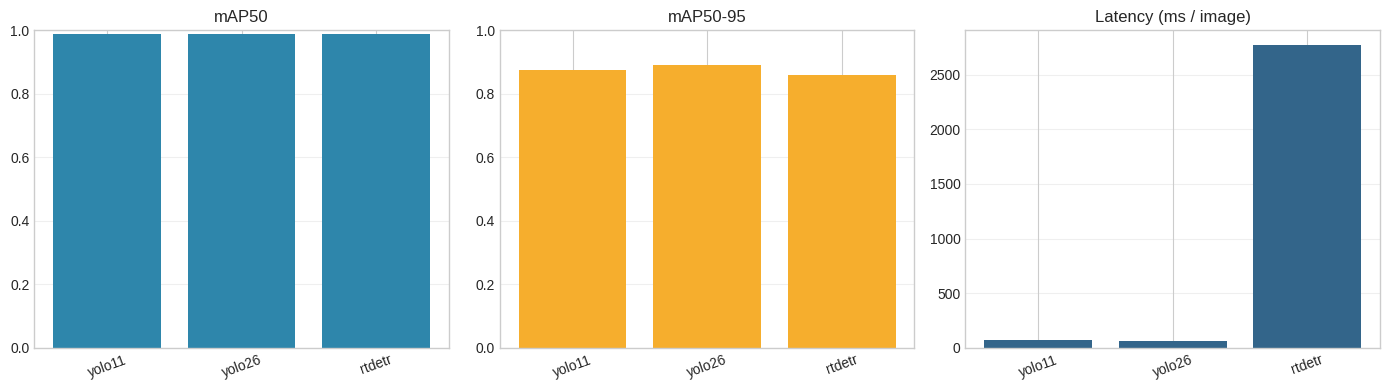

In [25]:
plot_df = results_df[results_df['status'] == 'ok'].copy()
if plot_df.empty:
    print('Tidak ada model yang bisa diplot karena semua model di-skip atau gagal load.')
else:
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    axes[0].bar(plot_df['model'], plot_df['mAP50'], color='#2E86AB')
    axes[0].set_title('mAP50')
    axes[0].set_ylim(0, 1)

    axes[1].bar(plot_df['model'], plot_df['mAP50-95'], color='#F6AE2D')
    axes[1].set_title('mAP50-95')
    axes[1].set_ylim(0, 1)

    axes[2].bar(plot_df['model'], plot_df['latency_ms_per_image'], color='#33658A')
    axes[2].set_title('Latency (ms / image)')

    for ax in axes:
        ax.grid(axis='y', alpha=0.3)
        ax.tick_params(axis='x', rotation=20)

    plt.tight_layout()
    plt.show()


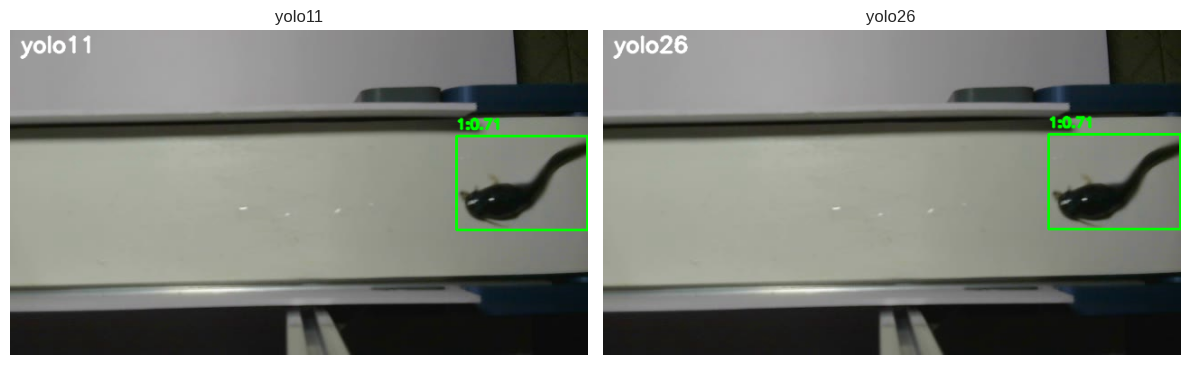

In [26]:
sample_image = image_files[50]
image_bgr = cv2.imread(str(sample_image))
if image_bgr is None:
    raise FileNotFoundError(sample_image)

fig, axes = plt.subplots(1, len(MODEL_SPECS), figsize=(6 * len(MODEL_SPECS), 6))
if len(MODEL_SPECS) == 1:
    axes = [axes]

for ax, (model_name, spec) in zip(axes, MODEL_SPECS.items()):
    model_dir = spec['model_dir']
    num_classes = spec['num_classes']
    if num_classes != DATASET_NUM_CLASSES:
        ax.imshow(cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB))
        ax.set_title(f'{model_name}\nskipped: class mismatch')
        ax.axis('off')
        continue

    if model_name not in sample_visuals:
        try:
            net = load_ncnn_net(model_dir)
            detections, _, image_bgr_vis = infer_single_image(net, sample_image, img_size=IMG_SIZE, conf_thres=CONF_THRES, nms_iou_thres=NMS_IOU_THRES)
        except Exception as exc:
            ax.imshow(cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB))
            ax.set_title(f'{model_name}\nload error: {exc}')
            ax.axis('off')
            continue
    else:
        image_bgr_vis, detections = sample_visuals[model_name]

    canvas = draw_detections(image_bgr_vis, detections, title=model_name)
    ax.imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))
    ax.set_title(model_name)
    ax.axis('off')

plt.tight_layout()
plt.show()


In [27]:
summary_rows = []
for model_name in ['yolo11', 'yolo26', 'rtdetr']:
    row = results_df[results_df['model'] == model_name].iloc[0].to_dict()
    summary_rows.append({
        'model': row['model'],
        'status': row['status'],
        'mAP50': row['mAP50'],
        'mAP50-95': row['mAP50-95'],
        'latency_ms_per_image': row['latency_ms_per_image'],
    })

print(pd.DataFrame(summary_rows).to_string(index=False))

for model_name in ['yolo11', 'yolo26']:
    if model_name in predictions_cache:
        pred_total = sum(len(items) for items in predictions_cache[model_name]['predictions_by_class'].values())
        gt_total = sum(len(items) for class_map in predictions_cache[model_name]['ground_truth_by_class'].values() for items in class_map.values())
        print(f'{model_name}: predictions={pred_total}, ground_truth_boxes={gt_total}')

print('RT-DETR enabled:', ENABLE_RTDETR_EVAL)


 model status    mAP50  mAP50-95  latency_ms_per_image
yolo11     ok 0.986881  0.875081             72.480734
yolo26     ok 0.986881  0.890093             66.325667
rtdetr     ok 0.986881  0.860008           2766.232359
yolo11: predictions=144, ground_truth_boxes=145
yolo26: predictions=144, ground_truth_boxes=145
RT-DETR enabled: True
